# Portfolio Optimization: Lagrange Multipliers and Kuhn–Tucker Conditions

Companion notebook to Elton, Gruber, Brown & Goetzmann, *Modern Portfolio Theory and Investment Analysis*.

**Road map**

| Part | Problem | Method |
|---|---|---|
| 1 | Two assets, no optimization | Direct formulas, correlation sweep |
| 2 | $\min \sigma_p^2$ s.t. $X'\mathbf{1}=1$ | Lagrangian, one equality constraint |
| 3 | $\min \sigma_p^2$ s.t. $X'R=R_p^*,\ X'\mathbf{1}=1$ | Lagrangian, two equality constraints |
| 4 | $\max \theta=(R_p-R_f)/\sigma_p$ | Linear system in $Z=\lambda X$ |
| 5 | Part 3 **plus** $X_i\ge 0$ | Quadratic program, Kuhn–Tucker conditions |
| 6 | Part 5 with $\sum_i \lvert X_i\rvert = 1$ | Lintner's short-sale definition |

Throughout: $R$ = vector of expected returns, $\Sigma$ = variance–covariance matrix, $X$ = weight vector,
$\mathbf{1}$ = vector of ones, $R_f$ = risk-free rate.

## Setup

### The universe

Five asset classes with **forward-looking** annualized inputs taken from J.P. Morgan's 2026 Long-Term Capital
Market Assumptions (10–15 year horizon, USD, data as of 30 September 2025) — not historical averages.
$R_f = 4.2\%$ stands in for the USD cash assumption.

Reading the code cell line by line:

| line | what it does |
|---|---|
| `R` | expected (geometric, forward-looking) annual returns, one per asset, in decimals |
| `sd` | forward-looking annual standard deviations $\sigma_i$ |
| `Corr` | the correlation matrix $C$: symmetric, ones on the diagonal, $\rho_{ij}\in[-1,1]$ |
| `Sigma = np.outer(sd, sd) * Corr` | $\Sigma = D\,C\,D$ with $D=\operatorname{diag}(\sigma_i)$, elementwise: $\sigma_{ij} = \sigma_i\sigma_j\rho_{ij}$ |
| `one` | the vector $\mathbf{1}$ used in every budget constraint $X'\mathbf{1}=1$ |
| `Rf` | risk-free rate, used only in Part 4 (tangency) and in Sharpe ratios |
| `np.linalg.eigvalsh(Corr)` | eigenvalues of a *symmetric* matrix (`h` = Hermitian; faster and returns them sorted and real) |

`np.outer(sd, sd)` builds the $n\times n$ matrix of products $\sigma_i\sigma_j$, and multiplying it elementwise
by `Corr` turns correlations into covariances. Built this way $\Sigma$ is automatically symmetric, but *not*
automatically positive definite — that depends on `Corr` being a valid correlation matrix, which is why the
eigenvalue check matters. All eigenvalues $>0$ means $\Sigma^{-1}$ exists and $X'\Sigma X$ is strictly convex,
so every optimum below is *the* global optimum. If you hand-edit a correlation and an eigenvalue goes
negative, the "minimum variance" portfolio becomes meaningless (you can construct portfolios with negative
variance), so the check is not decoration.

Two things change relative to a textbook-style illustrative set-up, and they drive most of the results below:

- **Returns are compressed.** The whole spread is 4.8% to 7.8%. Equity risk premia over cash are ~2.5–3.6pp,
  because elevated starting valuations are a drag in the CMA framework.
- **Bonds are no longer uncorrelated with equities** ($\rho$ between 0.09 and 0.23), and equities correlate
  0.70–0.88 with each other. The diversification free lunch is smaller than in the classic example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def _fmt(v): return f"{v:.4f}"
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", _fmt)
plt.rcParams.update({"figure.figsize": (8, 5.5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

names = ["US Large Cap", "US Small Cap", "Intl Developed", "Emerging Mkts", "Agg Bonds"]
n = len(names)
R = np.array([0.067, 0.074, 0.075, 0.078, 0.048])
sd = np.array([0.1597, 0.2050, 0.1822, 0.1934, 0.0484])
Corr = np.array([
    [1.00, 0.88, 0.85, 0.70, 0.23],
    [0.88, 1.00, 0.78, 0.71, 0.15],
    [0.85, 0.78, 1.00, 0.81, 0.17], 
    [0.70, 0.71, 0.81, 1.00, 0.09], 
    [0.23, 0.15, 0.17, 0.09, 1.00],
])
Sigma = np.outer(sd, sd) * Corr
one = np.ones(n)
Rf = 0.042 
eig = np.linalg.eigvalsh(Corr)
print("eigen Corr:", eig, " -> PSD:", (eig > 0).all())

eigen Corr: [0.0875 0.1814 0.3514 0.9691 3.4107]  -> PSD: True


In [2]:
inputs = pd.DataFrame({
    "E(R) fwd geom 10-15y": R, 
    "sigma fwd": sd, 
    "Ex-ante Sharpe standalone (R-Rf)/sd": (R - Rf) / sd
}, index=names)

print("Expected returns and risk (JPM 2026 LTCMA, forward-looking, NOT historical)\n")
print(inputs)
print()

print("Correlation matrix C (JPM 2026 USD, 10-15y, no exact zeros)\n")
print(pd.DataFrame(Corr, index=names, columns=names).round(2))
print()

print("Variance-covariance matrix Sigma = outer(sd,sd)*Corr\n")
print(pd.DataFrame(Sigma, index=names, columns=names).round(5))
print()

eigs = np.linalg.eigvalsh(Sigma)
eigs_corr = np.linalg.eigvalsh(Corr)
print("Eigenvalues of Sigma:", np.round(eigs, 6))
print("Eigenvalues of Corr:", np.round(eigs_corr, 4))
print("Positive definite (Sigma):", bool(np.all(eigs > 0)), 
      "| PD (Corr):", bool(np.all(eigs_corr > 0)),
      "| condition number Sigma:", round(eigs.max() / eigs.min(), 1))

Expected returns and risk (JPM 2026 LTCMA, forward-looking, NOT historical)

                E(R) fwd geom 10-15y  sigma fwd  \
US Large Cap                  0.0670     0.1597   
US Small Cap                  0.0740     0.2050   
Intl Developed                0.0750     0.1822   
Emerging Mkts                 0.0780     0.1934   
Agg Bonds                     0.0480     0.0484   

                Ex-ante Sharpe standalone (R-Rf)/sd  
US Large Cap                                 0.1565  
US Small Cap                                 0.1561  
Intl Developed                               0.1811  
Emerging Mkts                                0.1861  
Agg Bonds                                    0.1240  

Correlation matrix C (JPM 2026 USD, 10-15y, no exact zeros)

                US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  \
US Large Cap          1.0000        0.8800          0.8500         0.7000   
US Small Cap          0.8800        1.0000          0.7800         0.7100   

In [3]:
def port_return(X, R=R):
    '''E(R_p) = X'R'''
    return float(X @ R)

def port_var(X, Sigma=Sigma):
    '''sigma_p^2 = X'Sigma X'''
    return float(X @ Sigma @ X)

def port_sd(X, Sigma=Sigma):
    '''sigma_p = sqrt(X'Sigma X)'''
    return float(np.sqrt(port_var(X, Sigma)))

def summarize(X, label):
    '''Print weights, return, risk and Sharpe ratio of a portfolio.'''
    r, s = port_return(X), port_sd(X)
    print(f"{label}")
    print(pd.Series(X, index=names, name="weight").to_frame().T)
    print(f"  E(Rp) = {r:.4%}   sigma_p = {s:.4%}   sum(X) = {X.sum():.4f}   "
          f"theta = {(r - Rf) / s:.4f}\n")
    return r, s

**Interpretation.** All five eigenvalues are strictly positive, so $\Sigma$ is positive definite and the
first-order conditions derived below are necessary *and* sufficient. Two features of these inputs are worth
noticing before any optimization happens, because they explain almost everything that follows.

**The standalone Sharpe ratios are nearly identical**: 0.156 (US large), 0.156 (small), 0.181 (international),
0.186 (EM), 0.124 (bonds). When assets are this close on reward-per-risk, mean–variance optimization
differentiates them almost entirely through the *covariance* structure, not through returns.

**The condition number of $\Sigma$ is 57**, driven by equity correlations of 0.70–0.88. A poorly conditioned
$\Sigma$ means $\Sigma^{-1}$ amplifies small differences between expected returns, which is exactly why the
frontier weights further down swing so violently for such a narrow band of target returns. That sensitivity is
a property of the data, not a bug in the method — and it is the standard argument for shrinkage estimators.

Bonds carry only 0.6pp of expected excess return over cash, but with $\sigma = 4.84\%$ they are by far the
lowest-variance asset, so expect them to dominate the low-risk end of every frontier below.

## Part 1 — Two assets: how correlation bends the curve

With two assets and weights $X_1$, $X_2 = 1 - X_1$:

$$E(R_p) = X_1 R_1 + X_2 R_2$$
$$\sigma_p^2 = X_1^2\sigma_1^2 + X_2^2\sigma_2^2 + 2X_1X_2\sigma_1\sigma_2\rho_{12}$$

No optimization yet — this is just the opportunity set traced out as $X_1$ varies. Values $X_1 > 1$
(equivalently $X_2 < 0$) mean shorting asset 2 and putting the proceeds into asset 1.

The only term that depends on $\rho_{12}$ is the cross term, and it enters *linearly*. Lower correlation
shrinks $\sigma_p$ at every $X_1$ without touching $E(R_p)$ at all, so the whole curve is pushed left as
$\rho$ falls: this is diversification, in one equation.

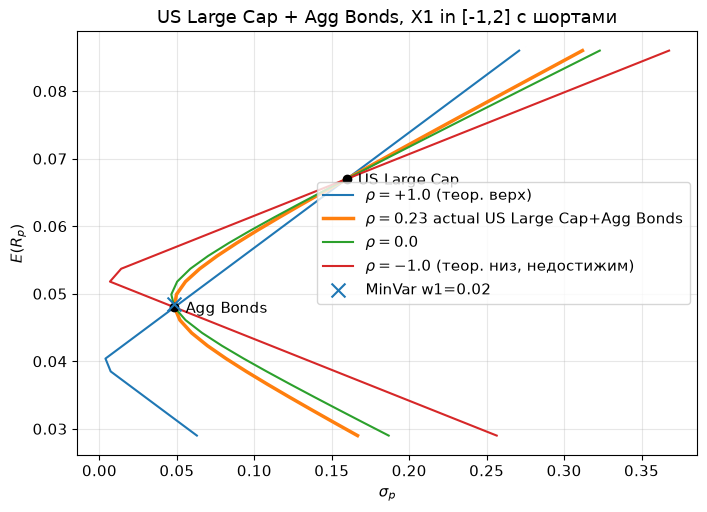

In [4]:
i1, i2 = 0, 4
R1, R2 = R[i1], R[i2]
sd1, sd2 = sd[i1], sd[i2]
rho_actual = Corr[i1, i2]

X1 = np.linspace(-1.0, 2.0, 31) 
X2 = 1.0 - X1
Rp_2a = X1 * R1 + X2 * R2

def sd_two_asset(rho, x1=X1, x2=X2, s1=sd1, s2=sd2):
    var = x1**2 * s1**2 + x2**2 * s2**2 + 2 * x1 * x2 * s1 * s2 * rho
    return np.sqrt(np.maximum(var, 0))

rhos_to_plot = [1.0, rho_actual, 0.0, -1.0]
curves = {r: sd_two_asset(r) for r in rhos_to_plot}

fig, ax = plt.subplots()
ax.plot(curves[1.0], Rp_2a, label=r"$\rho=+1.0$ (теор. верх)")
ax.plot(curves[rho_actual], Rp_2a, label=fr"$\rho={rho_actual:.2f}$ actual {names[i1]}+{names[i2]}", lw=2.5)
ax.plot(curves[0.0], Rp_2a, label=r"$\rho=0.0$")
ax.plot(curves[-1.0], Rp_2a, label=r"$\rho=-1.0$ (теор. низ, недостижим)")

ax.scatter([sd1, sd2], [R1, R2], color="black", zorder=5)
ax.annotate(names[i1], (sd1, R1), textcoords="offset points", xytext=(8, -4))
ax.annotate(names[i2], (sd2, R2), textcoords="offset points", xytext=(8, -4))

w_star = (sd2**2 - rho_actual*sd1*sd2) / (sd1**2 + sd2**2 - 2*rho_actual*sd1*sd2)
ax.scatter([sd_two_asset(rho_actual, np.array([w_star]), np.array([1-w_star]))[0]],
           [w_star*R1 + (1-w_star)*R2], marker="x", s=100, zorder=6, label=f"MinVar w1={w_star:.2f}")

ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title(f"{names[i1]} + {names[i2]}, X1 in [-1,2] с шортами")
ax.legend(); plt.show()

**Interpretation.** At $\rho=+1$ the two assets are redundant and the opportunity set collapses to a
straight line: no risk reduction is available. As $\rho$ falls the curve bows to the left, and at $\rho=-1$ it
becomes two straight segments meeting at $\sigma_p = 0$ — a perfect hedge exists. Every curve passes through
the same two endpoints (the individual assets) because correlation never affects $E(R_p)$.

The realistic case here is $\rho = 0.23$ between US large cap and bonds, which bows only slightly. Compare
this with the textbook illustration that assumes near-zero stock–bond correlation: the leftward bulge there is
much larger. Under these CMA inputs the minimum-variance mix of the two is roughly 2% equities — real, but a
far cry from the "add 10-15% stocks and lower your risk" result you get with $\rho \approx 0$.

## Part 2 — Global minimum variance portfolio (one equality constraint)

Minimize variance subject *only* to the budget constraint. No target return yet:

$$\min_X \tfrac{1}{2} X'\Sigma X \quad \text{s.t.} \quad X'\mathbf{1} = 1$$

Lagrangian:

$$L = \tfrac{1}{2}X'\Sigma X - \lambda\,(X'\mathbf{1} - 1)$$

First-order conditions ($n+1$ equations, $n+1$ unknowns):

$$\frac{\partial L}{\partial X} = \Sigma X - \lambda\mathbf{1} = 0
\quad\Longrightarrow\quad X = \lambda\,\Sigma^{-1}\mathbf{1}$$
$$\frac{\partial L}{\partial \lambda} = -(X'\mathbf{1} - 1) = 0
\quad\Longrightarrow\quad X'\mathbf{1} = 1$$

Substituting the first into the second gives $\lambda = 1/(\mathbf{1}'\Sigma^{-1}\mathbf{1})$ and hence

$$\boxed{\;X^{*} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}'\Sigma^{-1}\mathbf{1}}\;}$$

The $\tfrac{1}{2}$ in front of the variance is pure convenience — it cancels the 2 from differentiating the
quadratic form and only rescales $\lambda$. Numerically we use `np.linalg.solve(Sigma, one)` rather than
`np.linalg.inv(Sigma) @ one`: same answer, better conditioning, fewer flops.

In [5]:
Sinv_1 = np.linalg.solve(Sigma, one)     
Sinv_R = np.linalg.solve(Sigma, R)       

A_ = one @ Sinv_1        
B_ = one @ Sinv_R        
C_ = R   @ Sinv_R       
D_ = A_ * C_ - B_**2     

X_gmv = Sinv_1 / A_                    
lam_gmv = 1.0 / A_                   

print(f"A = 1'S^-1 1 = {A_:.4f}   B = 1'S^-1 R = {B_:.4f}   "
      f"C = R'S^-1 R = {C_:.4f}   D = AC - B^2 = {D_:.4f}\n")
R_gmv, sd_gmv = summarize(X_gmv, "Global minimum variance portfolio (short sales allowed)")
print(f"Lagrange multiplier lambda = {lam_gmv:.6f}   "
      f"(= sigma_gmv^2 = {port_var(X_gmv):.6f}, since X*'Sigma X* = lambda * X*'1)")

print(f"\nEqual-weight portfolio sigma: {port_sd(one / n):.4%}")
print(f"Lowest single-asset sigma:    {sd.min():.4%} ({names[int(sd.argmin())]})")
print(f"GMV sigma:                    {sd_gmv:.4%}")

A = 1'S^-1 1 = 439.4857   B = 1'S^-1 R = 21.5709   C = R'S^-1 R = 1.0847   D = AC - B^2 = 11.4179

Global minimum variance portfolio (short sales allowed)
        US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds
weight       -0.0128        0.0012         -0.0171         0.0585     0.9702
  E(Rp) = 4.9082%   sigma_p = 4.7701%   sum(X) = 1.0000   theta = 0.1485

Lagrange multiplier lambda = 0.002275   (= sigma_gmv^2 = 0.002275, since X*'Sigma X* = lambda * X*'1)

Equal-weight portfolio sigma: 13.7647%
Lowest single-asset sigma:    4.8400% (Agg Bonds)
GMV sigma:                    4.7701%


In [6]:
sub = [i1, i2]                                   
Sigma_sub = Sigma[np.ix_(sub, sub)]
X_gmv_sub = np.linalg.solve(Sigma_sub, np.ones(2))
X_gmv_sub /= X_gmv_sub.sum()

grid  = np.arange(-1.0, 2.0 + 1e-9, 0.001)       
Xg    = np.column_stack([grid, 1 - grid])
var_g = np.einsum("ij,jk,ik->i", Xg, Sigma_sub, Xg)  
k     = int(var_g.argmin())

print(f"Closed form  : X1 = {X_gmv_sub[0]: .5f}, X2 = {X_gmv_sub[1]: .5f}, "
      f"sigma = {np.sqrt(X_gmv_sub @ Sigma_sub @ X_gmv_sub):.6%}")
print(f"Brute sweep  : X1 = {grid[k]: .5f}, X2 = {1 - grid[k]: .5f}, "
      f"sigma = {np.sqrt(var_g[k]):.6%}")
print(f"Difference in X1: {abs(X_gmv_sub[0] - grid[k]):.2e}  (grid step is 0.001)")

Closed form  : X1 =  0.02325, X2 =  0.97675, sigma = 4.826415%
Brute sweep  : X1 =  0.02300, X2 =  0.97700, sigma = 4.826417%
Difference in X1: 2.50e-04  (grid step is 0.001)


**Interpretation.** The GMV portfolio is 97% bonds, plus a 5.9% long in emerging markets, funded by small
shorts in US large cap ($-1.3\%$) and international developed ($-1.7\%$). The objective ignores returns
entirely, so every one of those positions is a pure covariance play.

Why EM is the only equity held long: it has the *lowest* correlation with bonds in the matrix (0.09), so it is
the cheapest available diversifier. US large cap and international correlate 0.23 and 0.17 with bonds and
0.85 with each other — they add variance to a bond-dominated portfolio without offering anything the other
equities don't, so the optimizer sells them.

The multiplier $\lambda = 0.002275$ equals the GMV variance itself, which follows from
$X^{*\prime}\Sigma X^{*} = \lambda X^{*\prime}\mathbf{1} = \lambda$. And note how little the GMV improves on
simply holding bonds: 4.770% versus 4.840%, a 7bp gain. With realistic stock–bond correlations there is very
little variance left to diversify away at that end of the frontier.

The brute-force sweep on the two-asset subset lands on the closed-form answer to within one grid step, which
confirms the algebra.

## Part 3 — The efficient frontier (two equality constraints)

Now pin the expected return to a target $R_p^*$:

$$\min_X \tfrac{1}{2}X'\Sigma X \quad \text{s.t.} \quad X'R = R_p^*, \quad X'\mathbf{1} = 1$$

$$L = \tfrac{1}{2}X'\Sigma X - \lambda_1 (X'R - R_p^{*}) - \lambda_2 (X'\mathbf{1} - 1)$$

First-order conditions:

$$\frac{\partial L}{\partial X} = \Sigma X - \lambda_1 R - \lambda_2\mathbf{1} = 0, \qquad
X'R = R_p^{*}, \qquad X'\mathbf{1} = 1$$

which is a linear system of $n+2$ equations in $n+2$ unknowns $[X;\lambda_1;\lambda_2]$:

$$\begin{bmatrix} \Sigma & -R & -\mathbf{1} \\ R' & 0 & 0 \\ \mathbf{1}' & 0 & 0 \end{bmatrix}
\begin{bmatrix} X \\ \lambda_1 \\ \lambda_2 \end{bmatrix} =
\begin{bmatrix} \mathbf{0} \\ R_p^{*} \\ 1 \end{bmatrix}$$

Because the system is linear in the right-hand side, and $R_p^*$ enters only there, the solution is **affine
in the target return**:

$$X(R_p^{*}) = g + h\,R_p^{*}, \qquad
g = \frac{C\,\Sigma^{-1}\mathbf{1} - B\,\Sigma^{-1}R}{D}, \qquad
h = \frac{A\,\Sigma^{-1}R - B\,\Sigma^{-1}\mathbf{1}}{D}$$

with $A,B,C,D$ from Part 2. This is the *two-fund separation* result: every frontier portfolio is a
combination of the two fixed portfolios $g$ and $g+h$. Substituting back gives the frontier hyperbola

$$\sigma_p^2(R_p^{*}) = \frac{A R_p^{*2} - 2B R_p^{*} + C}{D}$$

Minimizing that over $R_p^*$ gives $R_{gmv} = B/A$ and $\sigma^2_{gmv} = 1/A$ — the Part 2 answer, recovered.

We implement the block system explicitly (it *is* the FOCs, one line of code) and then use the affine form to
sweep the whole frontier without re-solving anything.

In [7]:
def frontier_block_solve(Rp_target):
    '''Solve the (n+2)x(n+2) first-order-condition system directly.
    Returns (X, lambda_1, lambda_2). This matrix IS dL/dX = 0 plus the two constraints.'''
    M = np.zeros((n + 2, n + 2))
    M[:n, :n]  = Sigma
    M[:n,  n]  = -R
    M[:n,  n+1] = -one
    M[n,  :n]  = R
    M[n+1, :n] = one
    rhs = np.concatenate([np.zeros(n), [Rp_target], [1.0]])
    sol = np.linalg.solve(M, rhs)
    return sol[:n], sol[n], sol[n + 1]

g_vec = (C_ * Sinv_1 - B_ * Sinv_R) / D_
h_vec = (A_ * Sinv_R - B_ * Sinv_1) / D_

Rp_test = 0.10
X_block, lam1, lam2 = frontier_block_solve(Rp_test)
X_affine = g_vec + h_vec * Rp_test
print(f"Target Rp* = {Rp_test:.2%}")
print("block-system X :", np.round(X_block, 6))
print("affine     X   :", np.round(X_affine, 6))
print("max |difference|:", f"{np.abs(X_block - X_affine).max():.2e}")
print(f"lambda_1 = {lam1:.6f}   lambda_2 = {lam2:.6f}")
print(f"\nGMV check from the algebra:  B/A = {B_/A_:.6%} vs Part 2 {R_gmv:.6%}"
      f"   |   1/sqrt(A) = {1/np.sqrt(A_):.6%} vs Part 2 {sd_gmv:.6%}")

Target Rp* = 10.00%
block-system X : [-0.7026  0.4095  0.9878  0.9344 -0.6291]
affine     X   : [-0.7026  0.4095  0.9878  0.9344 -0.6291]
max |difference|: 7.99e-15
lambda_1 = 1.959872   lambda_2 = -0.093919

GMV check from the algebra:  B/A = 4.908205% vs Part 2 4.908205%   |   1/sqrt(A) = 4.770101% vs Part 2 4.770101%


max |hyperbola - X'SigmaX| : 5.34e-16


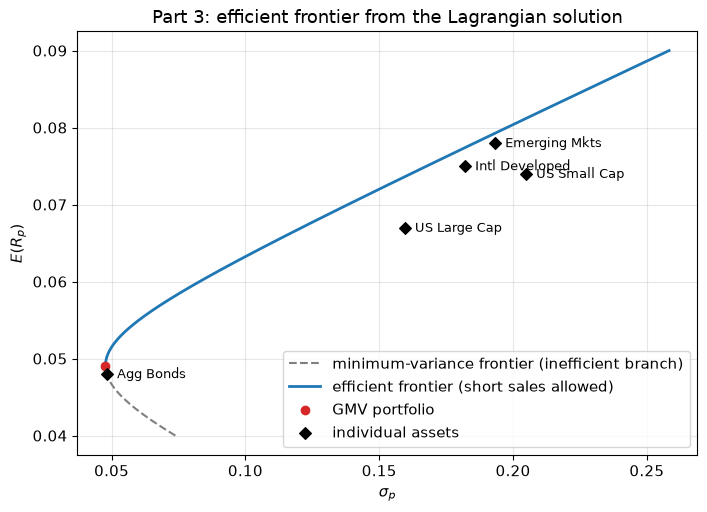

In [8]:
Rp_grid = np.linspace(0.04, 0.09, 400) 
X_grid   = g_vec[None, :] + Rp_grid[:, None] * h_vec[None, :] 
sd_grid  = np.sqrt((A_ * Rp_grid**2 - 2 * B_ * Rp_grid + C_) / D_)

sd_check = np.sqrt(np.einsum("ij,jk,ik->i", X_grid, Sigma, X_grid))
print("max |hyperbola - X'SigmaX| :", f"{np.abs(sd_grid - sd_check).max():.2e}")

efficient = Rp_grid >= R_gmv          

fig, ax = plt.subplots()
ax.plot(sd_grid[~efficient], Rp_grid[~efficient], "--", color="gray",
        label="minimum-variance frontier (inefficient branch)")
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2,
        label="efficient frontier (short sales allowed)")
ax.scatter([sd_gmv], [R_gmv], color="tab:red", zorder=5, label="GMV portfolio")
ax.scatter(sd, R, color="black", marker="D", s=35, zorder=5, label="individual assets")
for name, s, r in zip(names, sd, R):
    ax.annotate(name, (s, r), textcoords="offset points", xytext=(7, -3), fontsize=9)
ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title("Part 3: efficient frontier from the Lagrangian solution")
ax.legend(loc="lower right"); plt.show()

In [9]:
targets = np.sort(np.array([0.048, R_gmv, 0.055, 0.065, 0.07, 0.078, 0.09]))
W = g_vec[None, :] + targets[:, None] * h_vec[None, :]

table = pd.DataFrame(W, columns=names)
table.insert(0, "Rp* target", targets)
table["sigma_p"]  = np.sqrt(np.einsum("ij,jk,ik->i", W, Sigma, W))
table["sum(X)"]   = W.sum(axis=1)
table["sum|X|"]   = np.abs(W).sum(axis=1)
print("Frontier weights as the target return rises (negative = short sale)\n")
print(table.to_string(index=False))

Frontier weights as the target return rises (negative = short sale)

 Rp* target  US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  sigma_p  sum(X)  sum|X|
     0.0480        0.0018       -0.0074         -0.0385         0.0399     1.0042   0.0482  1.0000  1.0919
     0.0491       -0.0128        0.0012         -0.0171         0.0585     0.9702   0.0477  1.0000  1.0599
     0.0550       -0.0930        0.0487          0.0997         0.1603     0.7843   0.0602  1.0000  1.1860
     0.0650       -0.2285        0.1289          0.2970         0.3324     0.4702   0.1097  1.0000  1.4569
     0.0700       -0.2962        0.1690          0.3957         0.4184     0.3132   0.1383  1.0000  1.5924
     0.0780       -0.4046        0.2331          0.5536         0.5560     0.0619   0.1856  1.0000  1.8092
     0.0900       -0.5672        0.3293          0.7904         0.7624    -0.3150   0.2583  1.0000  2.7643


**Interpretation.** Reading down the table, **US large cap is the funding leg**: it goes from roughly flat at
the GMV point to $-40\%$ at a 7.8% target and $-57\%$ at 9%. The reason is visible in the inputs — it has the
lowest expected return of the four equity blocks (6.7%) while correlating 0.88 with small cap and 0.85 with
international. It is nearly the same risk exposure for less return, so the optimizer shorts it and buys
international and EM instead. Bonds drain from 100% down to 6% and eventually go short themselves once the
target exceeds what the equities can deliver unlevered.

`sum(X)` stays at exactly 1 everywhere (the budget constraint binds), while `sum|X|` climbs to 2.76 — that
gap between $\sum X_i$ and $\sum|X_i|$ is exactly what Part 6 restricts.

Notice how *fast* the weights move: a 3pp change in target return swings US large cap by 40pp of the
portfolio. That is the compressed-returns problem from the Setup section showing up in practice. With
expected returns this close together and correlations this high, the optimizer needs enormous long/short
positions to manufacture small return differences, which is precisely why unconstrained mean–variance weights
are so unstable under realistic CMA inputs.

The frontier is a hyperbola in $(\sigma_p, R_p)$ space and the GMV portfolio is its leftmost point, as the
plot confirms. Everything below the red dot is the inefficient lower branch: same risk, less return.

## Part 4 — Tangency portfolio: maximizing the Sharpe ratio

Now maximize the reward-to-variability ratio

$$\theta = \frac{E(R_p) - R_f}{\sigma_p} = \frac{X'R - R_f}{\sqrt{X'\Sigma X}}
\qquad \text{s.t.}\quad X'\mathbf{1}=1$$

Setting $\partial\theta/\partial X_i = 0$ and clearing denominators gives, for every asset $i$,

$$R_i - R_f = \sum_{j=1}^{n} Z_j \sigma_{ij}, \qquad\text{i.e.}\qquad \Sigma Z = R - R_f\mathbf{1}$$

where $Z_j = \lambda X_j$ absorbs a positive scale factor $\lambda = \theta/\sigma_p$. The $Z_i$ are not
weights — they only become weights after normalizing, which is where $X'\mathbf{1}=1$ re-enters:

$$X_i = \frac{Z_i}{\sum_j Z_j}$$

This is the EGBG "solve for $Z$, then scale" recipe, and it is a *linear* system: the nonlinear Sharpe
maximization collapses to $n$ equations because the objective is scale-invariant.

In [10]:
if Rf >= R_gmv:
    print("Rf >= R_gmv -> tangency not efficient, Sharpe max fails")
excess = R - Rf * one
Z = np.linalg.solve(Sigma, excess)          
X_tan = Z / Z.sum()         

print("Z (unscaled solution):", np.round(Z, 4), "  sum(Z) =", round(Z.sum(), 4), "\n")
R_tan, sd_tan = summarize(X_tan, f"Tangency portfolio (Rf = {Rf:.1%})")
theta_tan = (R_tan - Rf) / sd_tan

X_check = g_vec + h_vec * R_tan
print("Same portfolio from the Part 3 frontier formula? max|diff| =",
      f"{np.abs(X_check - X_tan).max():.2e}")

print(f"\nSharpe of tangency portfolio : {theta_tan:.4f}")
print(f"Sharpe of GMV portfolio      : {(R_gmv - Rf) / sd_gmv:.4f}")
print(f"Best single-asset Sharpe     : {((R - Rf) / sd).max():.4f} "
      f"({names[int(((R - Rf) / sd).argmax())]})")

Z (unscaled solution): [-0.3918  0.2122  0.4594  0.6291  2.2036]   sum(Z) = 3.1125 

Tangency portfolio (Rf = 4.2%)
        US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds
weight       -0.1259        0.0682          0.1476         0.2021     0.7080
  E(Rp) = 5.7429%   sigma_p = 7.0408%   sum(X) = 1.0000   theta = 0.2191

Same portfolio from the Part 3 frontier formula? max|diff| = 4.44e-15

Sharpe of tangency portfolio : 0.2191
Sharpe of GMV portfolio      : 0.1485
Best single-asset Sharpe     : 0.1861 (Emerging Mkts)


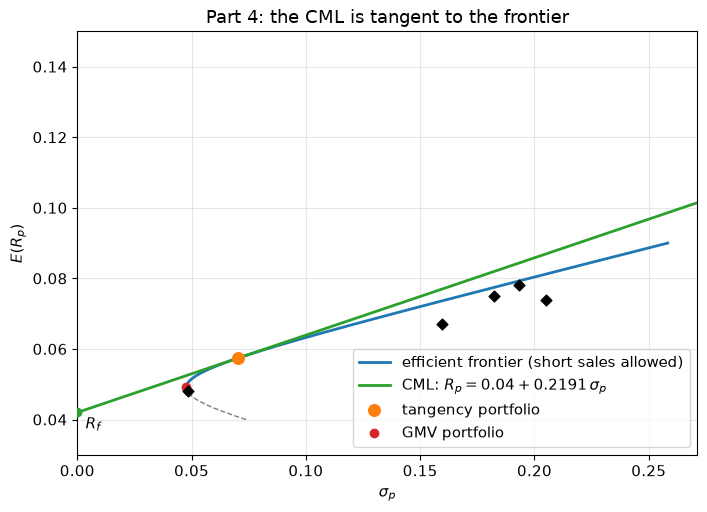

CML touches the frontier at sigma_p = 0.0712 (tangency sigma_p = 0.0704)


In [11]:
sd_cml = np.linspace(0, sd_grid.max() * 1.05, 100)
cml    = Rf + theta_tan * sd_cml            

fig, ax = plt.subplots()
ax.plot(sd_grid[~efficient], Rp_grid[~efficient], "--", color="gray", lw=1)
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2,
        label="efficient frontier (short sales allowed)")
ax.plot(sd_cml, cml, color="tab:green", lw=2,
        label=fr"CML: $R_p = {Rf:.2f} + {theta_tan:.4f}\,\sigma_p$")
ax.scatter([0], [Rf], color="tab:green", zorder=5)
ax.annotate("$R_f$", (0, Rf), textcoords="offset points", xytext=(6, -12))
ax.scatter([sd_tan], [R_tan], color="tab:orange", s=70, zorder=6, label="tangency portfolio")
ax.scatter([sd_gmv], [R_gmv], color="tab:red", zorder=5, label="GMV portfolio")
ax.scatter(sd, R, color="black", marker="D", s=30, zorder=5)
ax.set_xlim(0, sd_grid.max() * 1.05); ax.set_ylim(0.03, 0.15)
ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title("Part 4: the CML is tangent to the frontier")
ax.legend(loc="lower right"); plt.show()

frontier_at = np.interp(sd_cml, sd_grid[efficient], Rp_grid[efficient])
touch = np.abs(cml - frontier_at).argmin()
print(f"CML touches the frontier at sigma_p = {sd_cml[touch]:.4f} "
      f"(tangency sigma_p = {sd_tan:.4f})")

**Interpretation.** The tangency portfolio is 70.8% bonds, 20.2% EM, 14.8% international and 6.8% small cap,
funded by a 12.6% short in US large cap. Its Sharpe ratio of 0.219 beats the best single asset (EM at 0.186)
and comfortably beats the GMV portfolio (0.149) — which is the point: the GMV portfolio minimizes risk, not
risk-adjusted return.

It is bond-heavy for a structural reason. With standalone Sharpe ratios this tightly clustered, the optimizer
has little return-based reason to prefer equities, so it loads up on the asset with the lowest variance and
picks up the equity risk premium through a small, diversified equity sleeve.

The CML touches the frontier at $\sigma_p \approx 0.0712$ against a tangency $\sigma_p$ of 0.0704 — the
difference is the resolution of the 100-point grid used to draw the line, not an error. The CML's slope *is*
$\theta$, so "maximize the Sharpe ratio" and "find the steepest line from $R_f$ that still touches the
feasible set" are the same problem stated two ways.

## Part 5 — No short sales: quadratic programming and Kuhn–Tucker

Add $X_i \ge 0$ for all $i$. These are *inequality* constraints, so plain Lagrange multipliers are no longer
enough; the Kuhn–Tucker (KKT) conditions take over. Write the Lagrangian with one multiplier $\mu_i \ge 0$
per non-negativity constraint:

$$L = \tfrac{1}{2}X'\Sigma X - \lambda_1(X'R - R_p^{*}) - \lambda_2(X'\mathbf{1}-1) - \sum_i \mu_i X_i$$

The KKT conditions are:

| | condition |
|---|---|
| stationarity | $(\Sigma X)_i - \lambda_1 R_i - \lambda_2 - \mu_i = 0$ for all $i$ |
| primal feasibility | $X'R = R_p^{*}$, $X'\mathbf{1}=1$, $X_i \ge 0$ |
| dual feasibility | $\mu_i \ge 0$ |
| complementary slackness | $\mu_i X_i = 0$ for all $i$ |

Complementary slackness is the whole story: for any asset actually held ($X_i>0$) we need $\mu_i = 0$, so the
old equality-constrained condition $(\Sigma X)_i = \lambda_1 R_i + \lambda_2$ still holds. For an asset at a
**corner solution** ($X_i = 0$), $\mu_i$ is allowed to be strictly positive, and

$$\mu_i = (\Sigma X)_i - \lambda_1 R_i - \lambda_2 \;\ge\; 0$$

is the *reduced cost* of that asset: the marginal increase in the objective from being forced to hold a tiny
bit of it. A positive $\mu_i$ says "this asset would want a negative weight if it were allowed one".

**Recovering the multipliers.** `scipy` does not hand back clean duals, so we recover them from the KKT system
itself. Take the free set $F = \{i : X_i > 0\}$, where $\mu_i = 0$. Then

$$(\Sigma X)_i = \lambda_1 R_i + \lambda_2 \quad \text{for } i \in F$$

is an overdetermined linear system in $(\lambda_1, \lambda_2)$; solve it by least squares, then read off
$\mu = \Sigma X - \lambda_1 R - \lambda_2\mathbf{1}$ for *every* asset. The $\mu_i$ of the free assets should
come back at ~0 — that is the residual check that the solver actually converged to a KKT point.

In [12]:
TOL = 1e-7

def variance_obj(X):
    '''(1/2) X'Sigma X  -- the objective of every problem in this notebook.'''
    return 0.5 * X @ Sigma @ X

def variance_grad(X):
    '''d/dX of the objective = Sigma X  -- the first term of dL/dX.'''
    return Sigma @ X

def budget_con(X):
    '''X'1 - 1 = 0'''
    return X.sum() - 1.0

def budget_jac(X):
    return one

def return_con(X, Rp_target):
    '''X'R - Rp* = 0'''
    return X @ R - Rp_target

def return_jac(X, Rp_target):
    return R

def solve_no_short(Rp_target, x0=None):
    '''min (1/2) X'Sigma X  s.t.  X'R = Rp*, X'1 = 1, X >= 0.   SLSQP with analytic gradients.'''
    cons = [{"type": "eq", "fun": budget_con, "jac": budget_jac},
            {"type": "eq", "fun": return_con, "jac": return_jac, "args": (Rp_target,)}]
    if x0 is None:
        x0 = np.full(n, 1.0 / n)
    return minimize(variance_obj, x0, method="SLSQP", jac=variance_grad,
                    bounds=[(0.0, None)] * n, constraints=cons,
                    options={"maxiter": 500, "ftol": 1e-9})
    
def kkt_multipliers(X):
    '''Recover (lambda_1, lambda_2, mu) from the KKT stationarity conditions.'''
    free = X > TOL
    M = np.column_stack([R[free], one[free]])              
    (l1, l2), *_ = np.linalg.lstsq(M, (Sigma @ X)[free], rcond=None)
    mu = Sigma @ X - l1 * R - l2 * one                    
    return l1, l2, mu

print(f"Attainable returns with X >= 0: {R.min():.2%} to {R.max():.2%}")

res_gmv_ns = minimize(variance_obj, np.full(n, 1 / n), method="SLSQP", jac=variance_grad,
                      bounds=[(0.0, None)] * n,
                      constraints=[{"type": "eq", "fun": budget_con, "jac": budget_jac}])
X_gmv_ns = res_gmv_ns.x
R_gmv_ns, sd_gmv_ns = summarize(X_gmv_ns, "GMV portfolio, no short sales")

Attainable returns with X >= 0: 4.80% to 7.80%
GMV portfolio, no short sales
        US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds
weight        0.0000        0.0000          0.0000         0.0392     0.9608
  E(Rp) = 4.9177%   sigma_p = 4.7785%   sum(X) = 1.0000   theta = 0.1502



In [13]:
for Rp_star in [0.055, 0.065, 0.075]:  
    res = solve_no_short(Rp_star)
    X   = np.where(res.x < TOL, 0.0, res.x)          
    l1, l2, mu = kkt_multipliers(X)
    at_corner = X <= TOL

    print("=" * 78)
    print(f"Target Rp* = {Rp_star:.2%}   |  solver status {res.status} ({res.message})")
    print(f"sigma_p = {port_sd(X):.4%}   E(Rp) = {port_return(X):.4%}   sum(X) = {X.sum():.6f}")
    print(f"lambda_1 = {l1: .6f}   lambda_2 = {l2: .6f}")
    print(pd.DataFrame({"X_i": X,
                        "at corner (X=0)": at_corner,
                        "mu_i (reduced cost)": mu,
                        "X_i * mu_i": X * mu}, index=names))
    print(f"  corner assets      : {[names[i] for i in np.flatnonzero(at_corner)] or 'none'}")
    print(f"  min mu_i           : {mu.min(): .3e}   (dual feasibility needs mu >= 0)")
    print(f"  max |X_i * mu_i|   : {np.abs(X * mu).max():.3e}   (complementary slackness)")
    print(f"  unconstrained X    : {np.round(g_vec + h_vec * Rp_star, 4)}")
    print()

Target Rp* = 5.50%   |  solver status 0 (Optimization terminated successfully)
sigma_p = 6.0472%   E(Rp) = 5.5000%   sum(X) = 1.000000
lambda_1 =  0.232659   lambda_2 = -0.009139
                  X_i  at corner (X=0)  mu_i (reduced cost)  X_i * mu_i
US Large Cap   0.0000             True               0.0004      0.0000
US Small Cap   0.0078            False              -0.0000     -0.0000
Intl Developed 0.0638            False               0.0000      0.0000
Emerging Mkts  0.1691            False              -0.0000     -0.0000
Agg Bonds      0.7592            False              -0.0000     -0.0000
  corner assets      : ['US Large Cap']
  min mu_i           : -1.146e-06   (dual feasibility needs mu >= 0)
  max |X_i * mu_i|   : 1.938e-07   (complementary slackness)
  unconstrained X    : [-0.093   0.0487  0.0997  0.1603  0.7843]

Target Rp* = 6.50%   |  solver status 0 (Optimization terminated successfully)
sigma_p = 11.0590%   E(Rp) = 6.5000%   sum(X) = 1.000000
lambda_1 =  0.624

**Interpretation.** At all three targets the corner asset is **US large cap** — exactly the asset the
unrestricted solution wants to short (compare the `unconstrained X` line printed under each block, where it
sits at $-0.09$, $-0.23$, $-0.36$). Nothing else hits its bound, so the no-short constraint costs one degree
of freedom, no more.

The reduced cost grows with the target: $\mu = 0.0004 \to 0.0009 \to 0.0014$. Economically, the higher the
target return, the more the optimizer wishes it could short US large cap to fund international and EM, and
the more binding that zero floor becomes. Complementary slackness holds throughout — $X_i\mu_i$ is zero to
machine precision, and $\mu_i \approx 0$ for every asset actually held.

One numerical caveat: at $R_p^*=5.5\%$ the reported `min mu_i` is $-1.1\times10^{-6}$, slightly negative. That
is not a violation of dual feasibility, it is SLSQP's convergence tolerance near a newly active constraint:
US small cap sits at 0.0078, barely above the `TOL = 1e-7` free/corner cutoff, so the least-squares recovery
of $(\lambda_1,\lambda_2)$ inherits a little noise. Warm-starting from the previous solution, or re-solving
the equality-constrained problem on the free set and reading $\mu$ off that, cleans it up.

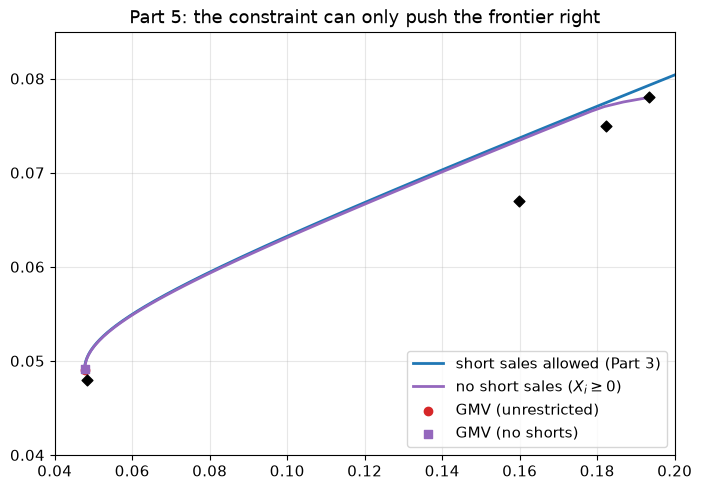

min (sigma_noshort - sigma_unrestricted) = 3.885e-05  (must be >= 0)
max extra risk from the constraint       = 0.7757% at Rp* = 7.80%


In [14]:
Rp_ns = np.linspace(R_gmv_ns, R.max(), 60)

sd_ns, W_ns = [], []
warm = np.full(n, 1 / n)
for t in Rp_ns:                                     
    res = solve_no_short(t, x0=warm)
    warm = res.x                                    
    X = np.where(res.x < TOL, 0.0, res.x)
    sd_ns.append(port_sd(X)); W_ns.append(X)
sd_ns = np.array(sd_ns); W_ns = np.array(W_ns)

fig, ax = plt.subplots()
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2,
        label="short sales allowed (Part 3)")
ax.plot(sd_ns, Rp_ns, color="tab:purple", lw=2, label=r"no short sales ($X_i \geq 0$)")
ax.scatter([sd_gmv], [R_gmv], color="tab:red", zorder=5, label="GMV (unrestricted)")
ax.scatter([sd_gmv_ns], [R_gmv_ns], color="tab:purple", marker="s", zorder=5, label="GMV (no shorts)")
ax.scatter(sd, R, color="black", marker="D", s=30, zorder=5)
ax.set_xlim(0.04, 0.20)  
ax.set_ylim(0.04, 0.085) 
ax.set_title("Part 5: the constraint can only push the frontier right")
ax.legend(loc="lower right"); plt.show()

sd_un_at = np.sqrt((A_ * Rp_ns**2 - 2 * B_ * Rp_ns + C_) / D_)
print(f"min (sigma_noshort - sigma_unrestricted) = {(sd_ns - sd_un_at).min():.3e}  (must be >= 0)")
print(f"max extra risk from the constraint       = {(sd_ns - sd_un_at).max():.4%} "
      f"at Rp* = {Rp_ns[int((sd_ns - sd_un_at).argmax())]:.2%}")

In [15]:
pick = np.linspace(0, len(Rp_ns) - 1, 8).astype(int)
tab_ns = pd.DataFrame(W_ns[pick], columns=names)
tab_ns.insert(0, "Rp*", Rp_ns[pick])
tab_ns["sigma_p"] = sd_ns[pick]
tab_ns["# at corner"] = (W_ns[pick] <= TOL).sum(axis=1)
print("No-short-sales frontier: weights and corner count\n")
print(tab_ns.to_string(index=False))

No-short-sales frontier: weights and corner count

   Rp*  US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  sigma_p  # at corner
0.0492        0.0000        0.0000          0.0000         0.0392     0.9608   0.0478            3
0.0531        0.0000        0.0040          0.0348         0.1348     0.8265   0.0539            1
0.0570        0.0000        0.0120          0.0914         0.2071     0.6895   0.0688            1
0.0614        0.0000        0.0211          0.1551         0.2885     0.5353   0.0907            1
0.0653        0.0000        0.0291          0.2117         0.3608     0.3983   0.1123            1
0.0697        0.0000        0.0382          0.2754         0.4422     0.2442   0.1377            1
0.0736        0.0000        0.0462          0.3320         0.5146     0.1072   0.1609            1
0.0780        0.0000        0.0000          0.0000         1.0000     0.0000   0.1934            4


In [16]:
lo, hi = R_gmv_ns, R.max()         
mask_un = (Rp_grid >= lo) & (Rp_grid <= hi)

def fit_line(sigma, Rp):
    '''OLS of Rp on sigma_p: returns (intercept a, slope b, R^2).'''
    b, a = np.polyfit(sigma, Rp, 1)
    pred = a + b * sigma
    r2 = 1 - ((Rp - pred) ** 2).sum() / ((Rp - Rp.mean()) ** 2).sum()
    return a, b, r2

a_un, b_un, r2_un = fit_line(sd_grid[mask_un], Rp_grid[mask_un])
a_ns, b_ns, r2_ns = fit_line(sd_ns, Rp_ns)

print(f"Fitted over E(Rp) in [{lo:.2%}, {hi:.2%}]\n")
print(f"Short sales allowed : Rp = {a_un:.4f} + {b_un:.4f} * sigma_p   (R^2 = {r2_un:.4f})")
print(f"No short sales      : Rp = {a_ns:.4f} + {b_ns:.4f} * sigma_p   (R^2 = {r2_ns:.4f})")
print(f"\nSlope difference    : {b_un - b_ns:.4f}  ({(b_un / b_ns - 1) * 100:.2f}% steeper "
      f"when shorting is allowed)")
print(f"Max Sharpe (tangency, unrestricted) for reference: {theta_tan:.4f}")

Fitted over E(Rp) in [4.92%, 7.80%]

Short sales allowed : Rp = 0.0431 + 0.1937 * sigma_p   (R^2 = 0.9893)
No short sales      : Rp = 0.0432 + 0.1908 * sigma_p   (R^2 = 0.9875)

Slope difference    : 0.0029  (1.54% steeper when shorting is allowed)
Max Sharpe (tangency, unrestricted) for reference: 0.2191


**Interpretation.** The no-short-sales frontier lies weakly to the right of the unrestricted one everywhere
and never crosses it — the printed minimum gap is $+3.9\times10^{-5}$, and it *has* to be non-negative,
because $\{X : X\ge 0\}$ is a subset of the unrestricted feasible set, so constraining can only raise the
attained minimum variance. The cost peaks at the top of the range (78bp of extra $\sigma_p$ at a 7.8% target),
where the unrestricted solution wants its largest short.

Two structural differences. First, the constrained frontier *ends* at emerging markets (7.8%), the
highest-return asset: without shorting you cannot lever past your best asset. Second, it is piecewise — linear
segments joined at **corner portfolios**, visible in the "# at corner" column as it goes 3 (only bonds and EM
held at the GMV end) → 1 in the middle → 4 at the top (100% EM). This is Markowitz's critical line algorithm
in slow motion.

The fitted slopes reproduce the textbook comparison qualitatively — short sales allowed is steeper — but the
gap is small here: 0.1937 versus 0.1908, only 1.5% apart. Compare that with the classic illustrative set-up,
where the same exercise gives a difference around 7-8%. The constraint bites less under these inputs precisely
because only one asset (US large cap) wants to be short, and only modestly. **The economic content of a
no-short-sales constraint is entirely a function of how badly the unconstrained solution wanted to short.**

Two caveats on the fitted numbers: a straight line only approximates a hyperbola (see the $R^2$), and the
slope depends on the return range fitted over, so it is a comparison statistic, not a structural parameter.
The clean version of "slope" is the tangency Sharpe ratio, 0.2191.

## Part 6 — Lintner's alternative short-sale definition

The Part 3 formulation lets shorts be free: $\sum_i X_i = 1$ counts a $-50\%$ position as $-0.5$, so a
portfolio can be $150\%$ long and $50\%$ short with no penalty. Lintner's convention instead requires that
the *gross* exposure be normalized:

$$\sum_i \lvert X_i \rvert = 1 \quad\text{instead of}\quad \sum_i X_i = 1$$

which reflects the idea that short proceeds are held as collateral rather than being freely reinvested.
The constraint is non-differentiable at $X_i = 0$, so we use the standard convex reformulation: split each
weight into a long and short piece,

$$X_i = u_i - v_i, \qquad u_i, v_i \ge 0, \qquad \sum_i (u_i + v_i) = 1$$

Usually at most one of $u_i, v_i$ is nonzero, so $u_i + v_i = |X_i|$ and the constraint becomes linear —
convex, and safe for SLSQP. Two things to watch:

- $\sum_i X_i \le 1$ here. Shorting no longer frees up cash to reinvest, so a portfolio that shorts is not
  fully invested in net terms. This is exactly Lintner's economic point.
- If both $u_i>0$ and $v_i>0$ at the solution, the split is *slack* and the solver has actually optimized
  $\sum_i|X_i| \le 1$ rather than $=1$. That happens when the target return is reachable with less than full
  gross exposure. The code checks for it and excludes those points instead of quietly mislabelling them.

In [17]:
def net_weights(uv):
    '''X = u - v, where uv = [u, v] stacks the long and short legs.'''
    return uv[:n] - uv[n:]

def lintner_obj(uv):
    X = net_weights(uv)
    return 0.5 * X @ Sigma @ X

def lintner_grad(uv):
    '''dObj/du = Sigma X, dObj/dv = -Sigma X, by the chain rule through X = u - v.'''
    gradient = Sigma @ net_weights(uv)
    return np.concatenate([gradient, -gradient])

def gross_exposure_con(uv):
    '''sum(u) + sum(v) - 1 = 0   (equals sum|X| - 1 when no u_i, v_i pair is both positive)'''
    return uv.sum() - 1.0

def gross_exposure_jac(uv):
    return np.ones(2 * n)

def lintner_return_con(uv, Rp_target):
    return net_weights(uv) @ R - Rp_target

def lintner_return_jac(uv, Rp_target):
    return np.concatenate([R, -R])

def solve_lintner(Rp_target, x0=None):
    '''min (1/2)X'Sigma X  s.t.  X'R = Rp*, sum|X| = 1, using X = u - v with u, v >= 0.'''
    cons = [{"type": "eq", "fun": gross_exposure_con, "jac": gross_exposure_jac},
            {"type": "eq", "fun": lintner_return_con, "jac": lintner_return_jac,
             "args": (Rp_target,)}]
    if x0 is None:
        x0 = np.full(2 * n, 1.0 / (2 * n))
    res = minimize(lintner_obj, x0, method="SLSQP", jac=lintner_grad,
                   bounds=[(0.0, None)] * (2 * n), constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-12})
    return net_weights(res.x), res

Rp_lin = np.linspace(R_gmv_ns, R.max(), 40)
sd_lin, W_lin, gross_lin = [], [], []
warm_lin = np.full(2 * n, 1.0 / (2 * n))
for t in Rp_lin:
    X, res = solve_lintner(t, x0=warm_lin)
    warm_lin = res.x
    X = np.where(np.abs(X) < TOL, 0.0, X)
    sd_lin.append(port_sd(X)); W_lin.append(X); gross_lin.append(np.abs(X).sum())
sd_lin = np.array(sd_lin); W_lin = np.array(W_lin); gross_lin = np.array(gross_lin)

tight = np.abs(gross_lin - 1.0) < 1e-6
print(f"Points where sum|X| = 1 holds exactly: {tight.sum()} of {len(Rp_lin)}")
if (~tight).any():
    print(f"  slack at Rp* = {np.round(Rp_lin[~tight], 4)} "
          f"(sum|X| = {np.round(gross_lin[~tight], 4)}) -- excluded from the plot")

shorts = (W_lin < -TOL).any(axis=1)
print(f"Targets with at least one short position: {shorts.sum()} of {len(Rp_lin)}"
      f"  (up to Rp* = {Rp_lin[shorts].max():.4%})" if shorts.any() else "No shorts taken")

tab_lin = pd.DataFrame(W_lin[::6], columns=names)
tab_lin.insert(0, "Rp*", Rp_lin[::6])
tab_lin["sigma_p"] = sd_lin[::6]
tab_lin["sum(X)"]  = W_lin[::6].sum(axis=1)
tab_lin["sum|X|"]  = gross_lin[::6]
print("\nLintner frontier weights\n"); print(tab_lin.to_string(index=False))

sd_ns_at = np.interp(Rp_lin, Rp_ns, sd_ns)
sd_un_at_lin = np.sqrt((A_ * Rp_lin**2 - 2 * B_ * Rp_lin + C_) / D_)
comp = pd.DataFrame({"Rp*": Rp_lin, "unrestricted": sd_un_at_lin,
                     "Lintner": sd_lin, "no short": sd_ns_at})[tight]
print("\nsigma_p under the three regimes (every 6th point)\n")
print(comp.iloc[::6].to_string(index=False))

diff = (sd_lin - sd_un_at_lin)[tight]
below = diff < -1e-9
print(f"\nLintner sigma below the unrestricted frontier at {below.sum()} of {tight.sum()} points"
      f" (max by {(-diff[below]).max():.4%})" if below.any() else
      "\nLintner never dips below the unrestricted frontier")
print(f"These are exactly the targets where sum(X) < 1: "
      f"{np.round(Rp_lin[tight][W_lin[tight].sum(axis=1) < 1 - 1e-6], 4)}")

Points where sum|X| = 1 holds exactly: 40 of 40
Targets with at least one short position: 2 of 40  (up to Rp* = 4.9916%)

Lintner frontier weights

   Rp*  US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  sigma_p  sum(X)  sum|X|
0.0492       -0.0110        0.0028          0.0000         0.0789     0.9073   0.0472  0.9780  1.0000
0.0536        0.0000        0.0049          0.0435         0.1436     0.8079   0.0556  1.0000  1.0000
0.0580        0.0000        0.0141          0.1077         0.2257     0.6525   0.0737  1.0000  1.0000
0.0625        0.0000        0.0232          0.1720         0.3078     0.4970   0.0966  1.0000  1.0000
0.0669        0.0000        0.0323          0.2362         0.3899     0.3416   0.1215  1.0000  1.0000
0.0713        0.0000        0.0415          0.3004         0.4720     0.1861   0.1475  1.0000  1.0000
0.0758        0.0000        0.0506          0.3647         0.5540     0.0307   0.1740  1.0000  1.0000

sigma_p under the three regimes (ev

**Interpretation.** The Lintner frontier splits into two regimes here.

**Above roughly a 5% target, shorts disappear entirely** and it lies exactly on top of the no-short-sales
frontier — the two $\sigma_p$ columns in the comparison table agree to four decimals. The reason is a budget
calculation. Under $\sum X_i = 1$, shorting \$1 of US large cap hands you \$1 to spend elsewhere: a free
lever. Under $\sum|X_i| = 1$, that same short *consumes* \$1 of gross budget, so the round trip costs \$2 of
budget to add \$1 of net long exposure. Since the short leg here is worth only about 12-40bp of return
improvement, that double toll is not worth paying, and the optimizer simply stops shorting.

**At the two lowest targets it does short**, and there it dips slightly *left* of the unrestricted frontier
(by at most 5bp) rather than sitting between the two curves. That is not a solver error. Those are exactly
the points where $\sum X_i < 1$: short proceeds are collateral, not spendable cash, so the portfolio is not
fully invested in net terms, and scaling total exposure down mechanically lowers $\sigma_p$. The Lintner
feasible set is therefore *not* a subset of the $\sum X_i = 1$ set, so the frontiers are not strictly nested
at that end. To restore clean nesting, charge the uninvested remainder to cash at $R_f$ (so
$R_p = X'R + (1-\sum X_i)R_f$) or add $\sum X_i = 1$ as a third constraint — either works, at the cost of no
longer being Lintner's formulation.

The broader lesson: $\sigma_{\text{unrestricted}} \le \sigma_{\text{Lintner}} \le \sigma_{\text{no short}}$
holds when each feasible set genuinely nests inside the previous one, and $\sum|X_i|=1$ quietly breaks that
nesting by relaxing what "fully invested" means. Check the constraint set, not just the picture.

## Combined chart and summary

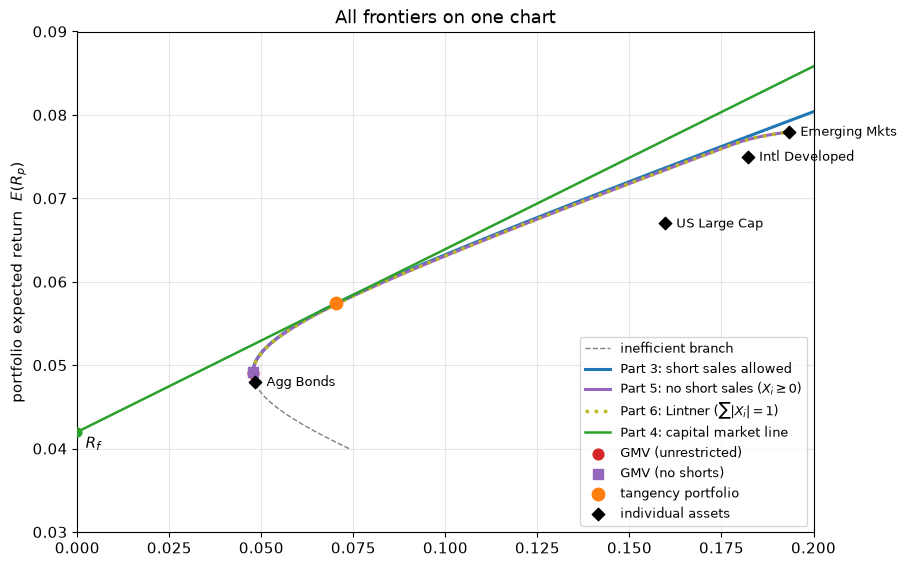

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

ax.plot(sd_grid[~efficient], Rp_grid[~efficient], "--", color="gray", lw=1,
        label="inefficient branch")
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2.2,
        label="Part 3: short sales allowed")
ax.plot(sd_ns, Rp_ns, color="tab:purple", lw=2.2, label=r"Part 5: no short sales ($X_i\geq0$)")
ax.plot(sd_lin[tight], Rp_lin[tight], color="tab:olive", lw=2.5, ls=":",
        label=r"Part 6: Lintner ($\sum|X_i|=1$)")
ax.plot(sd_cml, cml, color="tab:green", lw=1.8, label="Part 4: capital market line")

ax.scatter([sd_gmv], [R_gmv], color="tab:red", s=60, zorder=6, label="GMV (unrestricted)")
ax.scatter([sd_gmv_ns], [R_gmv_ns], color="tab:purple", marker="s", s=55, zorder=6,
           label="GMV (no shorts)")
ax.scatter([sd_tan], [R_tan], color="tab:orange", s=80, zorder=6, label="tangency portfolio")
ax.scatter([0], [Rf], color="tab:green", s=40, zorder=6)
ax.annotate("$R_f$", (0, Rf), textcoords="offset points", xytext=(6, -12))
ax.scatter(sd, R, color="black", marker="D", s=40, zorder=6, label="individual assets")
for name, s, r in zip(names, sd, R):
    ax.annotate(name, (s, r), textcoords="offset points", xytext=(8, -3), fontsize=9)

ax.set_xlim(0, 0.20)  
ax.set_ylim(0.03, 0.09)
ax.set_ylabel(r"portfolio expected return  $E(R_p)$")
ax.set_title("All frontiers on one chart")
ax.legend(loc="lower right", fontsize=9); plt.show()

In [19]:
summary = pd.DataFrame(
    [np.append(X_gmv,    [R_gmv,    sd_gmv,    (R_gmv - Rf) / sd_gmv]),
     np.append(X_tan,    [R_tan,    sd_tan,    theta_tan]),
     np.append(X_gmv_ns, [R_gmv_ns, sd_gmv_ns, (R_gmv_ns - Rf) / sd_gmv_ns])],
    index=["GMV (unrestricted)", "Tangency (unrestricted)", "GMV (no short sales)"],
    columns=names + ["E(Rp)", "sigma_p", "theta"])
print(summary.to_string())

                         US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  E(Rp)  sigma_p  theta
GMV (unrestricted)            -0.0128        0.0012         -0.0171         0.0585     0.9702 0.0491   0.0477 0.1485
Tangency (unrestricted)       -0.1259        0.0682          0.1476         0.2021     0.7080 0.0574   0.0704 0.2191
GMV (no short sales)           0.0000        0.0000          0.0000         0.0392     0.9608 0.0492   0.0478 0.1502


### What to take away

1. **Equality constraints → Lagrange multipliers → a linear system.** Minimizing a quadratic subject to
   linear equalities has a closed-form solution; the FOCs $\Sigma X = \lambda_1 R + \lambda_2\mathbf{1}$ are
   literally the matrix we solved. No iteration required.
2. **The multipliers are prices, not bookkeeping.** $\lambda$ in Part 2 equals the GMV variance; $\lambda_1$
   in Part 3 is the marginal variance cost of one more unit of target return; $\mu_i$ in Part 5 is the
   marginal cost of the no-shorting rule for asset $i$.
3. **Inequality constraints → KKT → a quadratic program.** Complementary slackness $\mu_i X_i = 0$ splits the
   assets into a free set (old equality conditions apply) and a corner set (multiplier goes positive). The
   solution becomes piecewise linear in $R_p^*$, joined at corner portfolios.
4. **Shrinking the feasible set can only hurt.** Unrestricted $\subseteq$ Lintner $\subseteq$ no-short-sales
   in achievable $\sigma_p$ at each target return — with the Lintner caveat in Part 6.
5. **Realistic inputs change the economics, not the math.** With JPM CMA numbers the expected returns are
   compressed and equity correlations are high, so: the GMV portfolio is almost entirely bonds, the frontier
   weights move violently for small changes in target return, and the no-short constraint costs far less
   (1.5% of slope) than it does in a textbook example with dispersed returns.

### Things worth trying next

- Set `Rf` to 3.5% or 5% and re-run: watch the tangency portfolio slide along the frontier.
- Raise US large cap's expected return by 50bp so it stops being the funding leg, and watch which asset gets
  shorted instead. Mean-variance weights are notoriously unstable in $R$ — this is the standard motivation
  for shrinkage estimators and Black-Litterman, and these compressed CMA returns make the point vividly.
- Cut every stock-bond correlation to 0.05 (the classic textbook assumption) and re-run Part 2. The GMV
  equity sleeve should grow substantially — that difference *is* the post-2022 correlation regime.
- Add a max-weight constraint ($X_i \le 0.4$) and inspect the multipliers on the *upper* bounds. With bonds
  at 97% of the GMV portfolio, that constraint will bind hard.